In [1]:
import json
import os
import pathlib
import sys

import dns.message
import matplotlib.pyplot
import matplotlib.style
import numpy
import polars

COLLECT_JSONS_DIR = pathlib.Path.cwd()

os.environ["COLLECT_JSONS_DIR"] = str(COLLECT_JSONS_DIR)
if str(COLLECT_JSONS_DIR) not in sys.path:
    sys.path.append(str(COLLECT_JSONS_DIR))

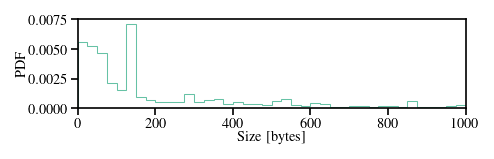

<Figure size 333.565x77.3079 with 0 Axes>

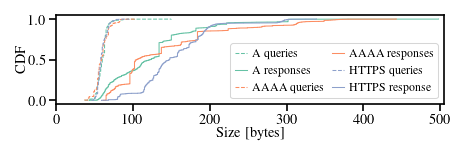

In [2]:
PLOT_DIR = COLLECT_JSONS_DIR / ".." / "plots"

matplotlib.style.use(COLLECT_JSONS_DIR / ".." / "mlenders_column.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 0.75,
)
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    matplotlib.colormaps["Set2"].colors,
)
fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)

df = polars.read_csv(COLLECT_JSONS_DIR / "2024-09-01-sample.csv", separator=";", quote_char="'")
# print(dns.message.from_wire(bytes.fromhex(df["a_r_dns_msg"][0])).to_text())
ax = matplotlib.pyplot.gca()
matplotlib.pyplot.hist(
    df["obj_len"],
    bins=numpy.arange(df["obj_len"].min() // 25 * 25, df["obj_len"].max() + 25, 25),
    density=True,
    histtype="step",
    linewidth=0.5,
)
ax.set_xlim((0, 1000))
ax.set_ylim((0.000, 0.0075))
ax.set_xlabel("Size [bytes]")
ax.set_ylabel("PDF")
matplotlib.pyplot.savefig(PLOT_DIR / "json_responses_hist.pdf", bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

matplotlib.pyplot.clf()
matplotlib.style.use(COLLECT_JSONS_DIR / ".." / "mlenders_column.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 0.75,
)
fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
ax = matplotlib.pyplot.gca()
https_q = df.filter(polars.col("https_q_dns_msg").is_null().not_())["https_q_dns_msg"].str.len_chars() // 2
aaaa_q = df.filter(polars.col("https_q_dns_msg").is_null().and_(polars.col("aaaa_q_dns_msg").is_null().not_()))["aaaa_q_dns_msg"].str.len_chars() // 2
a_q = df.filter(polars.col("https_q_dns_msg").is_null().and_(polars.col("aaaa_q_dns_msg").is_null().and_(polars.col("a_q_dns_msg").is_null().not_())))["a_q_dns_msg"].str.len_chars() // 2
https_r = df.filter(polars.col("https_r_dns_msg").is_null().not_())["https_r_dns_msg"].str.len_chars() // 2
aaaa_r = df.filter(polars.col("https_r_dns_msg").is_null().and_(polars.col("aaaa_r_dns_msg").is_null().not_()))["aaaa_r_dns_msg"].str.len_chars() // 2
a_r = df.filter(polars.col("https_r_dns_msg").is_null().and_(polars.col("aaaa_r_dns_msg").is_null().and_(polars.col("a_r_dns_msg").is_null().not_())))["a_r_dns_msg"].str.len_chars() // 2

matplotlib.pyplot.ecdf(
    a_q,
    color="C0",
    linestyle="--",
    label="A queries",
    linewidth=0.5,
)
matplotlib.pyplot.ecdf(
    a_r,
    color="C0",
    label="A responses",
    linewidth=0.5,
)
matplotlib.pyplot.ecdf(
    aaaa_q,
    color="C1",
    linestyle="--",
    label="AAAA queries",
    linewidth=0.5,
)
matplotlib.pyplot.ecdf(
    aaaa_r,
    color="C1",
    label="AAAA responses",
    linewidth=0.5,
)
matplotlib.pyplot.ecdf(
    https_q,
    color="C2",
    linestyle="--",
    label="HTTPS queries",
    linewidth=0.5,
)
matplotlib.pyplot.ecdf(
    https_r,
    color="C2",
    label="HTTPS response",
    linewidth=0.5,
)
ax.set_xlim((0, 505))
ax.set_ylim((-0.05, 1.05))
ax.set_xlabel("Size [bytes]")
ax.set_ylabel("CDF")
ax.legend(ncol=2)
matplotlib.pyplot.savefig(PLOT_DIR / "dns_messages_cdf.pdf", bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

In [3]:
df = df.to_pandas()

In [4]:
polars.DataFrame(
    [
        ("Total JSONs", df.shape[0]),
        ("HTTPS records for JSONs", df[~df["https_q_dns_msg"].isna()].shape[0]),
        ("AAAA records for JSONs", df[~df["aaaa_q_dns_msg"].isna()].shape[0]),
        ("!HTTPS & AAAA record", df[df["https_q_dns_msg"].isna() & ~df["aaaa_q_dns_msg"].isna()].shape[0]),
        ("A records", df[~df["a_q_dns_msg"].isna()].shape[0]),
        ("!HTTPS & !AAAA & A record", df[df["https_q_dns_msg"].isna() & df["aaaa_q_dns_msg"].isna() & ~df["a_q_dns_msg"].isna()].shape[0]),
        ("HTTPS & AAAA record", df[~df["https_q_dns_msg"].isna() & ~df["aaaa_q_dns_msg"].isna()].shape[0]),
    ],
    schema=["label", "count"],
    orient="row",
).to_pandas().set_index(["label"])

,count
label,
Total JSONs,60349
HTTPS records for JSONs,8561
AAAA records for JSONs,19866
!HTTPS & AAAA record,11998
A records,60349
!HTTPS & !AAAA & A record,39790
HTTPS & AAAA record,7868
